In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.renishaw import read_export

In [4]:
MOCK_RAMAN_FILE = Path(r"..\tests\raman\renishaw\TiO2_Julius_532_1acc_01.txt")

In [5]:
res = read_export(MOCK_RAMAN_FILE)

In [6]:
meta = res["meta"]
meta

{'instrument': 'Renishaw',
 'folder': '..\\tests\\raman\\renishaw',
 'filename': 'TiO2_Julius_532_1acc_01.txt'}

In [7]:
data = res["data"]
data

,wavelength,intensity
0,1638.658203,26.747444
1,1637.300781,28.521147
2,1635.941406,30.293678
3,1634.583984,35.627823
4,1633.224609,26.712030
...,...,...
1011,66.250000,43.519974
1012,64.527344,30.880707
1013,62.802734,26.665880
1014,61.078125,37.888199


In [8]:
raman = read_export(MOCK_RAMAN_FILE)
raman["meta"]

{'instrument': 'Renishaw',
 'folder': '..\\tests\\raman\\renishaw',
 'filename': 'TiO2_Julius_532_1acc_01.txt'}

In [9]:
data.columns

Index(['wavelength', 'intensity'], dtype='str')

In [10]:
raman = pp.raman.RamanData.from_renishaw_export(MOCK_RAMAN_FILE, export_type="txt", excitation_wavelength_nm=532)

In [11]:
raman.wavelength_nm

array([1638.658203, 1637.300781, 1635.941406, ...,   62.802734,
         61.078125,   59.353516], shape=(1016,))

In [12]:
raman.values.shape

(1016,)

In [13]:
raman.values

array([26.747444, 28.521147, 30.293678, ..., 26.66588 , 37.888199,
       37.88279 ], shape=(1016,))

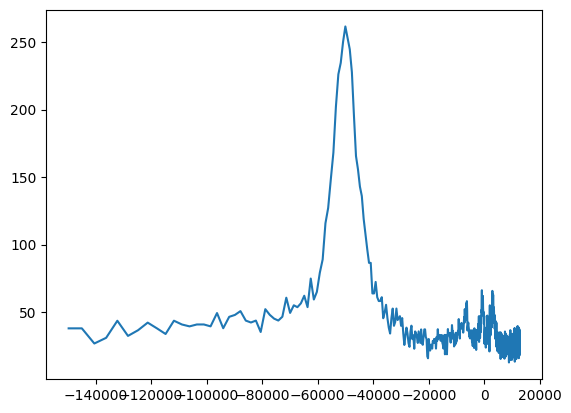

In [16]:
fig, ax = plt.subplots()
ax.plot(raman.shift_cm, raman.values.T)